# Исследовательский обзор обучающей выборки host

Цель:
- Проверить форму и качество выборки известных звезд-host.
- Посмотреть распределения признаков, баланс классов и стадий, а также покрытие металличности и фотометрических полей.
- Подготовить основу для контура `host-vs-field` без скрытых предположений об источнике данных.

In [1]:
# Настройка: корень репозитория, sys.path и базовые визуальные параметры.
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    # Ищем корень репозитория по наличию src и analysis.
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").exists() and (candidate / "analysis").exists():
            return candidate
    raise RuntimeError("Не удалось определить корень репозитория из текущей рабочей директории.")


REPO_ROOT = find_repo_root(Path.cwd())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

sns.set_theme(style="whitegrid", context="notebook")



In [2]:
# Импортируем V2-модули только после добавления src в sys.path.
from exohost.datasets.load_host_training_dataset import load_host_training_dataset
from exohost.db.engine import make_read_only_engine
from exohost.features.training_frame import HOST_NUMERIC_COLUMNS, prepare_host_training_frame



## Что делаем

- Загружаем выборку `host training` и нормализуем ее через текущий V2 pipeline.
- Смотрим отчет по пропускам, базовые статистики и распределения признаков.
- Проверяем баланс `spec_class/evolution_stage` и покрытие `spec_subclass`, если оно есть.
- Отдельно оцениваем, насколько источник выглядит полезным для будущего `host-vs-field` и расширения по subclass.

In [3]:
# Конфигурация notebook.
DOTENV_PATH = ".env"
HOST_LIMIT: int | None = None
PLOT_SAMPLE_SIZE = 5000


def build_missing_report(df: pd.DataFrame) -> pd.DataFrame:
    # Собираем компактную русифицированную таблицу пропусков по колонкам.
    rows: list[dict[str, object]] = []
    total_rows = int(df.shape[0])
    for column_name in df.columns.astype(str).tolist():
        missing_count = int(df.loc[:, column_name].isna().sum())
        rows.append(
            {
                "Название столбца": column_name,
                "Число пропусков": missing_count,
                "Доля пропусков": 0.0 if total_rows == 0 else float(missing_count / total_rows),
            }
        )
    return pd.DataFrame.from_records(rows).sort_values(
        ["Доля пропусков", "Название столбца"],
        ascending=[False, True],
        ignore_index=True,
    )


In [4]:
# Загружаем исходный и подготовленный датафреймы для host-выборки.
engine = make_read_only_engine(dotenv_path=DOTENV_PATH)
try:
    raw_host_df = load_host_training_dataset(engine, limit=HOST_LIMIT)
finally:
    engine.dispose()

host_df = prepare_host_training_frame(raw_host_df)
host_summary_df = pd.DataFrame(
    [
        {
            "Датафрейм": "Исходный host",
            "Число строк": int(raw_host_df.shape[0]),
            "Число столбцов": int(raw_host_df.shape[1]),
        },
        {
            "Датафрейм": "Подготовленный host",
            "Число строк": int(host_df.shape[0]),
            "Число столбцов": int(host_df.shape[1]),
        },
    ]
)

display(host_summary_df)
display(host_df.head())


,Датафрейм,Число строк,Число столбцов
0,Исходный host,3729,23
1,Подготовленный host,3729,24


,source_id,teff_gspphot,logg_gspphot,radius_flame,spec_class,evolution_stage,hostname,spec_subclass,ra_gaia,dec_gaia,...,phot_g_mean_mag,bp_rp,mh_gspphot,radius_gspphot,lum_flame,evolstage_flame,non_single_star,classprob_dsc_combmod_star,validation_factor,radius_gspphot_legacy
0,1000423609817438592,5805.4087,4.2058,1.241023,G,dwarf,TOI-1716,NaN,105.083340,56.824190,...,9.248471,0.777398,-0.1555,1.241023,1.578732,369.0,0,0.000001,1.0,1.2390
1,1004358968092652544,4877.7285,2.9234,5.274660,K,evolved,6 Lyn,NaN,97.696020,58.161130,...,5.609718,1.106288,-0.4920,5.274660,14.188626,605.0,0,0.999833,1.0,5.3019
2,1008018211509401728,4704.2935,2.3794,9.152734,K,evolved,HD 40956,NaN,91.662790,63.453876,...,6.150888,1.168737,-0.7080,9.152734,41.916515,524.0,0,0.999950,1.0,9.8188
3,101040381244467968,5089.5386,2.7439,10.318485,K,evolved,HD 14067,NaN,34.293343,23.767649,...,6.249009,1.198476,-0.0653,10.318485,64.361030,499.0,0,0.999907,1.0,10.2729
4,1011435012611767552,5952.1640,4.2514,1.339651,G,dwarf,HD 77946,NaN,136.777630,46.672420,...,8.859901,0.736798,-0.0171,1.339651,2.033248,349.0,0,0.000001,1.0,1.3441


In [5]:
# Пропуски, описательные статистики и покрытие подклассов.
missing_report_df = build_missing_report(raw_host_df)
numeric_columns = [name for name in HOST_NUMERIC_COLUMNS if name in host_df.columns]
host_describe_df = (
    host_df.loc[:, numeric_columns]
    .describe()
    .transpose()
    .rename_axis("Признак")
)

subclass_coverage_df = pd.DataFrame()
if "spec_subclass" in host_df.columns:
    subclass_coverage_df = (
        host_df.assign(spec_subclass_notna=host_df["spec_subclass"].notna())
        .groupby("spec_class", dropna=False)["spec_subclass_notna"]
        .agg(["count", "sum"])
        .reset_index()
        .rename(
            columns={
                "spec_class": "Спектральный класс",
                "count": "Число строк",
                "sum": "Строк с размеченным подклассом",
            }
        )
    )
    subclass_coverage_df["Доля строк с размеченным подклассом"] = (
        subclass_coverage_df["Строк с размеченным подклассом"]
        / subclass_coverage_df["Число строк"]
    )

display(missing_report_df.head(20))
display(host_describe_df)
display(subclass_coverage_df)


,Название столбца,Число пропусков,Доля пропусков
0,spec_subclass,3500,0.938589
1,evolstage_flame,225,0.060338
2,bp_rp,0,0.000000
3,classprob_dsc_combmod_star,0,0.000000
4,dec_gaia,0,0.000000
5,dist_arcsec,0,0.000000
6,evolution_stage,0,0.000000
7,hostname,0,0.000000
8,logg_gspphot,0,0.000000
9,lum_flame,0,0.000000


,count,mean,std,min,25%,50%,75%,max
Признак,,,,,,,,
teff_gspphot,3729.0,5352.801483,778.967520,2886.417200,4961.286600,5490.976000,5777.976000,12683.540000
logg_gspphot,3729.0,4.306245,0.368877,1.281700,4.192300,4.379200,4.520900,5.159100
radius_flame,3729.0,1.422344,2.375766,0.156765,0.824369,1.041382,1.400778,77.353424
radius_gspphot,3729.0,1.422344,2.375766,0.156765,0.824369,1.041382,1.400778,77.353424
lum_flame,3729.0,4.379211,47.179695,0.001537,0.397928,0.930886,2.062583,2572.393800
dist_arcsec,3729.0,0.044937,0.076557,0.000320,0.013576,0.025015,0.043241,0.949436
parallax,3729.0,8.554330,18.674801,0.046442,1.213073,2.484234,7.635427,310.577300
parallax_over_error,3729.0,429.127201,795.508012,0.514955,66.524600,160.548870,426.565000,10456.198000
ruwe,3729.0,1.212065,1.528479,0.616277,0.959333,1.006276,1.061729,39.460304


,Спектральный класс,Число строк,Строк с размеченным подклассом,Доля строк с размеченным подклассом
0,A,20,0,0.0
1,B,6,0,0.0
2,F,471,0,0.0
3,G,1945,0,0.0
4,K,1058,0,0.0
5,M,229,0,0.0


In [6]:
# Баланс классов и стадий.
class_distribution_df = (
    host_df.loc[:, "spec_class"]
    .astype(str)
    .value_counts(dropna=False)
    .rename_axis("Спектральный класс")
    .reset_index(name="Число строк")
)
stage_distribution_df = (
    host_df.loc[:, "evolution_stage"]
    .astype(str)
    .value_counts(dropna=False)
    .rename_axis("Стадия эволюции")
    .reset_index(name="Число строк")
)
class_stage_crosstab_df = pd.crosstab(
    host_df.loc[:, "spec_class"],
    host_df.loc[:, "evolution_stage"],
).rename_axis(index="Спектральный класс", columns="Стадия эволюции")

display(class_distribution_df)
display(stage_distribution_df)
display(class_stage_crosstab_df)


,Спектральный класс,Число строк
0,G,1945
1,K,1058
2,F,471
3,M,229
4,A,20
5,B,6


,Стадия эволюции,Число строк
0,dwarf,3406
1,evolved,323


Стадия эволюции,dwarf,evolved
Спектральный класс,,
A,15,5
B,4,2
F,411,60
G,1830,115
K,925,133
M,221,8


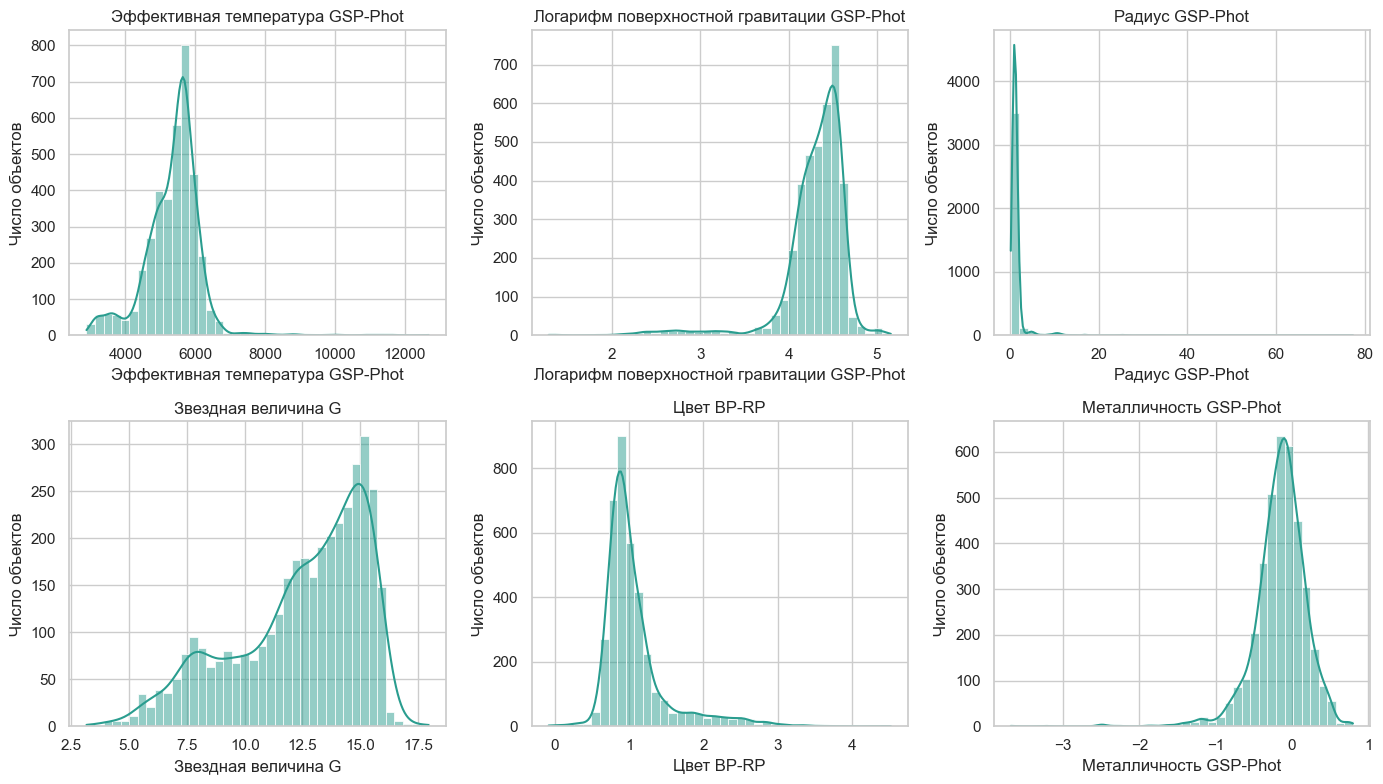

In [7]:
# Гистограммы основных признаков host-выборки.
plot_columns = [
    name
    for name in (
        "teff_gspphot",
        "logg_gspphot",
        "radius_gspphot",
        "phot_g_mean_mag",
        "bp_rp",
        "mh_gspphot",
    )
    if name in host_df.columns
]
plot_df = host_df.loc[:, plot_columns].dropna().head(PLOT_SAMPLE_SIZE)
axis_labels = {
    "teff_gspphot": "Эффективная температура GSP-Phot",
    "logg_gspphot": "Логарифм поверхностной гравитации GSP-Phot",
    "radius_gspphot": "Радиус GSP-Phot",
    "phot_g_mean_mag": "Звездная величина G",
    "bp_rp": "Цвет BP-RP",
    "mh_gspphot": "Металличность GSP-Phot",
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axis, column_name in zip(axes.flatten(), plot_columns, strict=False):
    sns.histplot(plot_df, x=column_name, bins=40, kde=True, ax=axis, color="#2A9D8F")
    axis.set_title(axis_labels.get(column_name, column_name))
    axis.set_xlabel(axis_labels.get(column_name, column_name))
    axis.set_ylabel("Число объектов")

for axis in axes.flatten()[len(plot_columns):]:
    axis.set_visible(False)

plt.tight_layout()


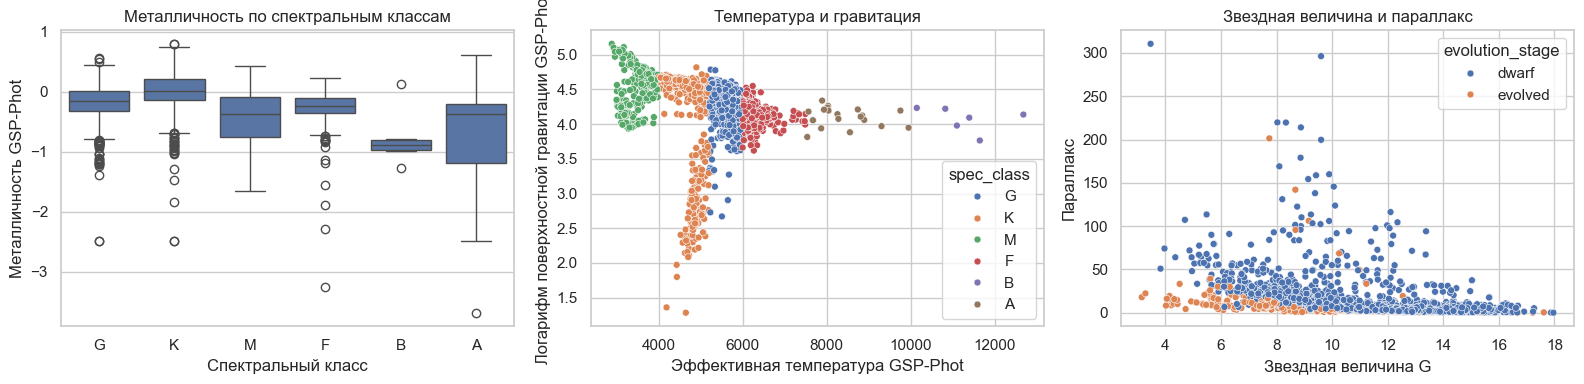

In [8]:
# Boxplot и scatter для host-источника.
scatter_df = host_df.head(PLOT_SAMPLE_SIZE).copy()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=scatter_df, x="spec_class", y="mh_gspphot", ax=axes[0])
axes[0].set_title("Металличность по спектральным классам")
axes[0].set_xlabel("Спектральный класс")
axes[0].set_ylabel("Металличность GSP-Phot")

sns.scatterplot(
    data=scatter_df,
    x="teff_gspphot",
    y="logg_gspphot",
    hue="spec_class",
    ax=axes[1],
    s=25,
)
axes[1].set_title("Температура и гравитация")
axes[1].set_xlabel("Эффективная температура GSP-Phot")
axes[1].set_ylabel("Логарифм поверхностной гравитации GSP-Phot")

sns.scatterplot(
    data=scatter_df,
    x="phot_g_mean_mag",
    y="parallax",
    hue="evolution_stage",
    ax=axes[2],
    s=25,
)
axes[2].set_title("Звездная величина и параллакс")
axes[2].set_xlabel("Звездная величина G")
axes[2].set_ylabel("Параллакс")

plt.tight_layout()


## Что смотреть в выводе

- Насколько чисто и разнообразно выглядит источник известных host-звезд?
- Хватает ли покрытия по `spec_class` и `evolution_stage`?
- Что происходит с `spec_subclass`: есть ли живая разметка или пока нет?
- Какие признаки уже сейчас выглядят полезными для host-контура и будущего ранжирования?